# House Prices                                                                                                                                                                                                  

## Data Loading

Import the required libraries and load the training and test datasets. 
Display the shape of each dataset and preview the first few rows to understand the structure of the data.

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Target Variable Analysis

Examine the distribution of `SalePrice`, the target variable, using summary statistics and a histogram. 
Since the raw distribution is right-skewed, apply a log transformation (`log1p`) to normalize it, 
which typically improves model performance for price-prediction tasks.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


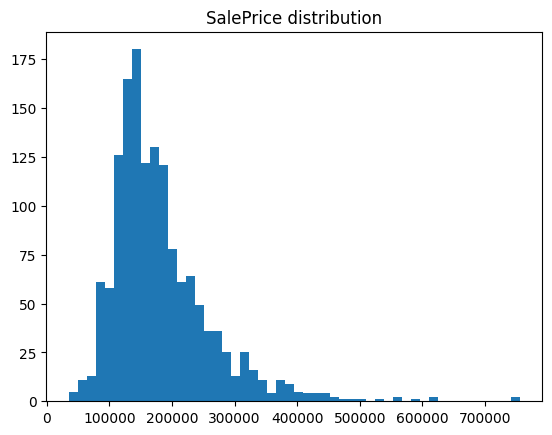

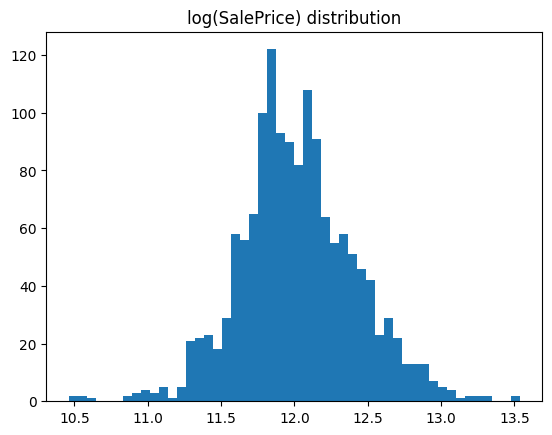

In [2]:
import matplotlib.pyplot as plt

print(train['SalePrice'].describe())

plt.hist(train['SalePrice'], bins=50)
plt.title("SalePrice distribution")
plt.show()


train['SalePrice_log'] = np.log1p(train['SalePrice'])
plt.hist(train['SalePrice_log'], bins=50)
plt.title("log(SalePrice) distribution")
plt.show()

## Missing Values Analysis

Identify columns with missing values, calculate the count and percentage of missing data for each, 
and sort them from highest to lowest to prioritize which features need cleaning.

In [3]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train)) * 100
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## Handling Missing Values

Fill missing values based on their meaning: categorical columns where a missing value indicates 
the absence of a feature (e.g. no garage, no basement) are filled with `'None'`, while related 
numerical columns are filled with `0` to stay consistent with that absence.

In [4]:

none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for df in [train, test]:
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')


zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for df in [train, test]:
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)


for df in [train, test]:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

for df in [train, test]:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())

print("Remaining missing in train:", train.isnull().sum().sum())
print("Remaining missing in test:", test.isnull().sum().sum())

Remaining missing in train: 0
Remaining missing in test: 0


## Outlier Detection and Removal

Visualize the relationship between `GrLivArea` and `SalePrice` with a scatter plot to spot outliers. 
Remove the small number of properties with unusually large living areas but low sale prices, 
since these anomalies could distort the model's learning.

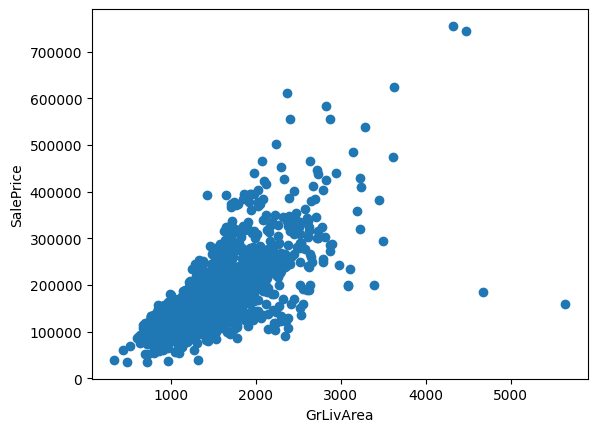

Train shape after outlier removal: (1458, 82)


In [5]:
plt.scatter(train['GrLivArea'], train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()


train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
print("Train shape after outlier removal:", train.shape)

## Feature Engineering

Create new features that capture more meaningful information for the model: 
combined square footage (`TotalSF`), property age at sale (`HouseAge`), years since last 
remodel (`RemodAge`), a weighted total bathroom count (`TotalBath`), and binary flags 
indicating the presence of a garage, pool, or second floor.

In [6]:
for df in [train, test]:
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['TotalBath'] = (df['FullBath'] + 0.5*df['HalfBath'] +
                        df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)

## Feature Preparation and Encoding

Separate the target variable (`SalePrice_log`) from the features, then combine the train 
and test sets so categorical variables can be one-hot encoded consistently across both. 
Split the encoded data back into training features (`X`) for model training.

In [7]:
train_ids = train['Id']
test_ids = test['Id']

y = train['SalePrice_log']
train_features = train.drop(['Id', 'SalePrice', 'SalePrice_log'], axis=1)
test_features = test.drop(['Id'], axis=1)


all_data = pd.concat([train_features, test_features], axis=0)
all_data = pd.get_dummies(all_data)

X = all_data.iloc[:len(train_features), :]
X_test = all_data.iloc[len(train_features):, :]

print(X.shape, X_test.shape)

(1458, 308) (1459, 308)


## Baseline Model: Ridge Regression

Establish a baseline performance using Ridge regression with 5-fold cross-validation. 
This gives a reference RMSE (on the log scale) to compare against more advanced models.

In [8]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = Ridge(alpha=10)

scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf)
print("Ridge RMSE (log scale):", -scores.mean())

Ridge RMSE (log scale): 0.11505106273132151


## XGBoost Model

Train an XGBoost regressor with tuned hyperparameters (learning rate, max depth, 
subsampling) and evaluate it using the same 5-fold cross-validation setup. 
Compare its RMSE against the Ridge baseline to measure improvement.

In [9]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

scores = cross_val_score(xgb, X, y, scoring='neg_root_mean_squared_error', cv=kf)
print("XGBoost RMSE (log scale):", -scores.mean())

XGBoost RMSE (log scale): 0.11538174861823103


## Environment Setup

Install the `xgboost` library in the current environment, since it is required 
for the model training step below.

In [10]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [11]:
import sys
print(sys.executable)


/usr/bin/python3.9


In [12]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3.9 -m pip install --upgrade pip


## Generate Submission File

Combine the predicted sale prices with their corresponding property IDs into the format 
required for submission, then export the results to `submission.csv`.

In [13]:
xgb.fit(X, y)
preds_log = xgb.predict(X_test)
preds = np.expm1(preds_log)  # reverse the log1p transform

## Generate Submission File

Combine the predicted sale prices with their corresponding property IDs into the format 
required for submission, then export the results to `submission.csv`.

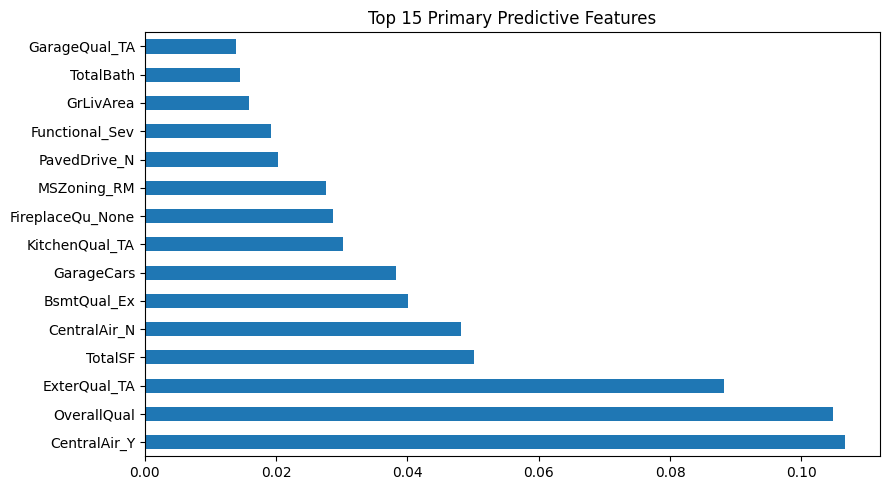

In [17]:
from xgboost import XGBRegressor

xgb_plot = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)
xgb_plot.fit(X, y)

(pd.Series(xgb_plot.feature_importances_, index=X.columns)
   .sort_values(ascending=False)
   .head(15)
   .plot(kind='barh', figsize=(9, 5)))

plt.title("Top 15 Primary Predictive Features")
plt.tight_layout()
plt.show()


In [18]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,127063.609375
1,1462,160038.703125
2,1463,185838.718750
3,1464,196983.218750
4,1465,182100.578125
